In [1]:
import pandas as pd
import sqlite3

In [2]:
conn = sqlite3.connect("../data/checking-logs.sqlite")

In [3]:


query_checker = """
SELECT timestamp 
FROM checker
WHERE uid NOT LIKE 'admin%'
"""
df_check = pd.read_sql(query_checker, conn)

df_check['timestamp'] = pd.to_datetime(df_check['timestamp'])
df_check['date'] = df_check['timestamp'].dt.date
commits_per_day = df_check.groupby('date').size().reset_index(name='commits')



In [4]:
query_view = """
SELECT datetime
FROM pageviews
WHERE uid NOT LIKE 'admin%'
"""

df_view = pd.read_sql(query_view, conn)
df_view['datetime'] = pd.to_datetime(df_view['datetime'])
df_view['date'] = df_view['datetime'].dt.date
views_per_day = df_view.groupby('date').size().reset_index(name='views')



In [5]:
merged_df = pd.merge(views_per_day, commits_per_day, on="date", how="inner")
merged_df["date"] = pd.to_datetime(merged_df["date"]) 
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   date     32 non-null     datetime64[ns]
 1   views    32 non-null     int64         
 2   commits  32 non-null     int64         
dtypes: datetime64[ns](1), int64(2)
memory usage: 900.0 bytes


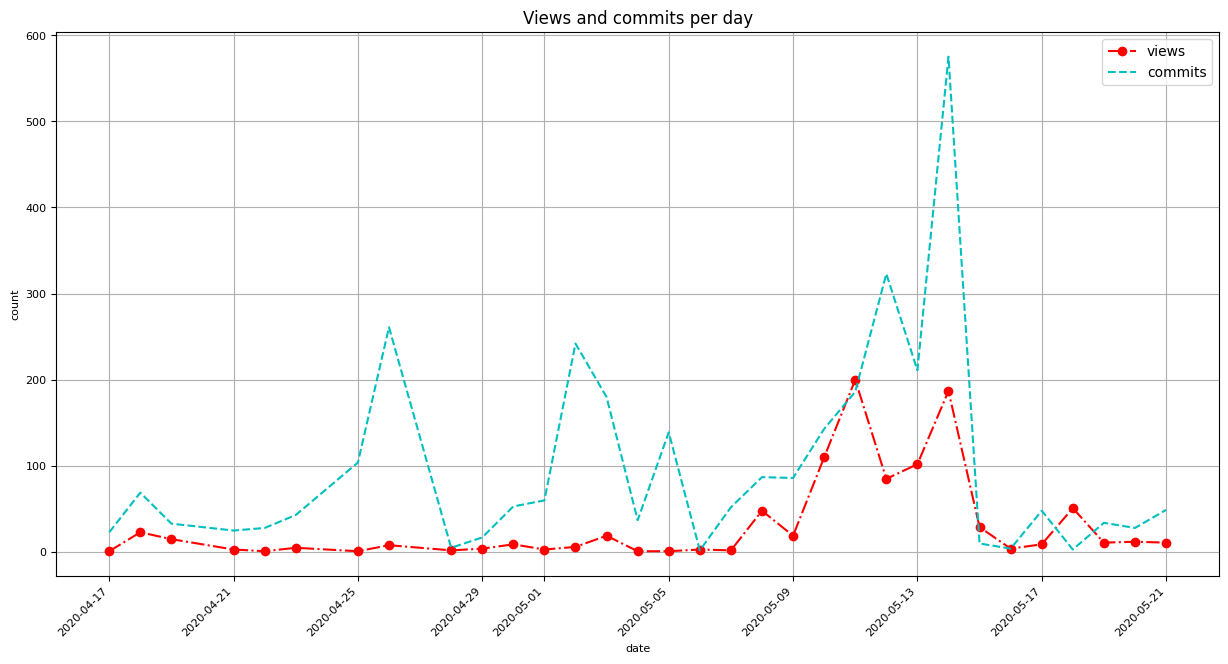

In [6]:
ax = merged_df.plot(x='date', y='views',  style='ro-.', label='views',figsize=(15, 8), fontsize=8 
)

merged_df.plot(ax=ax,x='date', y='commits',fontsize=8, style='c--', label='commits')

ax.set_title('Views and commits per day', fontsize=12)
ax.set_xlabel('date', fontsize=8)
ax.set_ylabel('count', fontsize=8)
ax.grid(True)
ax.tick_params(axis='x', rotation=45)

In [7]:
conn.close()

Сколько раз количество просмотров превышало 150?

In [8]:
print("Ответ :", merged_df[merged_df["views"] > 150].shape[0])

Ответ : 2
